In [66]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# 1. Fetch the dataset using its official UCI ID (565 is the Bone Marrow dataset)
bone_marrow = fetch_ucirepo(id=565)

# 2. Extract the features (X) and the target variable we want to predict (y)
X = bone_marrow.data.features
y = bone_marrow.data.targets

# 3. Combine them into one single Pandas DataFrame for our analysis
df = pd.concat([X, y], axis=1)

# 4. Display the first 5 rows to see what the data looks like
df.head()

,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,...,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
0,1,1,22.830137,0,1,0,1,1.0,1.0,0.0,...,1.0,7.20,1.338760,5.38,35.0,19,51,32,999,0
1,1,0,23.342466,0,1,0,-1,-1.0,1.0,0.0,...,1.0,4.50,11.078295,0.41,20.6,16,37,1000000,163,1
2,1,0,26.394521,0,1,0,-1,-1.0,1.0,0.0,...,1.0,7.94,19.013230,0.42,23.4,23,20,1000000,435,1
3,0,0,39.684932,1,1,0,1,2.0,1.0,1.0,...,NaN,4.25,29.481647,0.14,50.0,23,29,19,53,1
4,0,1,33.358904,0,0,0,1,2.0,0.0,1.0,...,1.0,51.85,3.972255,13.05,9.0,14,14,1000000,2043,0


In [67]:
# Check for missing values across the entire dataset
missing_values = df.isnull().sum()

# Filter to show ONLY the columns that actually have missing data
columns_with_missing = missing_values[missing_values > 0]
print("Columns with missing values:\n", columns_with_missing)

Columns with missing values:
 RecipientABO     1
RecipientRh      2
ABOmatch         1
CMVstatus       16
DonorCMV         2
RecipientCMV    14
Antigen          1
Allele           1
extcGvHD        31
CD3dCD34         5
CD3dkgx10d8      5
Rbodymass        2
dtype: int64


In [68]:
# Create a copy of the dataframe to keep the original intact
df_cleaned = df.copy()

# Loop through all the columns that we found had missing data
for col in columns_with_missing.index:
    
    # If a column has fewer than 10 unique values, it's likely categorical (like blood type)
    if df_cleaned[col].nunique() < 10:
        # Fill missing with the Mode
        mode_value = df_cleaned[col].mode()[0]
        df_cleaned[col] = df_cleaned[col].fillna(mode_value)
        
    # Otherwise, it's likely a continuous number (like body mass)
    else:
        # Fill missing with the Median
        median_value = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_value)

# Verify that all missing values are gone
print("Total missing values remaining:", df_cleaned.isnull().sum().sum())

Total missing values remaining: 0


I filled missing categorical values with the mode and continuous numerical values with the median to prevent data loss

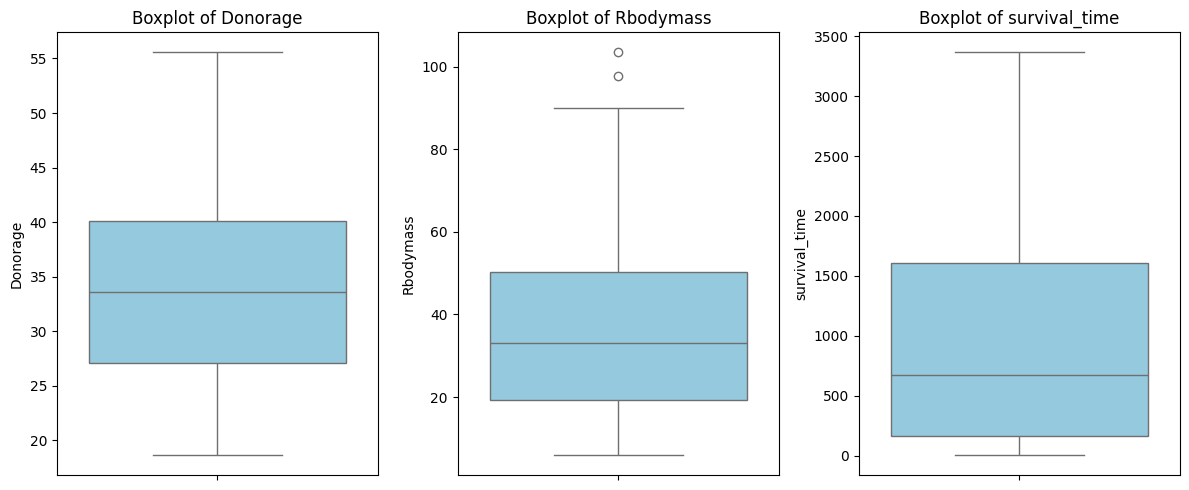

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# We will check three continuous features for outliers: Donor Age, Body Mass, and Survival Time
cols_to_check = ['Donorage', 'Rbodymass', 'survival_time']

# Set up the visual canvas
plt.figure(figsize=(12, 5))

# Draw a boxplot for each column
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_cleaned[col], color='skyblue')
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [70]:
# Calculate the 'whiskers' using the Interquartile Range (IQR)
Q1 = df_cleaned['Rbodymass'].quantile(0.25)
Q3 = df_cleaned['Rbodymass'].quantile(0.75)
IQR = Q3 - Q1

# Define the upper limit
upper_limit = Q3 + 1.5 * IQR

# Cap the outliers: anything above the limit becomes the limit
df_cleaned['Rbodymass'] = df_cleaned['Rbodymass'].clip(upper=upper_limit)

print(f"Rbodymass capped at: {upper_limit}")

Rbodymass capped at: 96.875


Significant outliers were identified in the Rbodymass feature using boxplot visualization. To prevent these extreme values from skewing the model while retaining the patient data, I applied a capping method. Specifically, values exceeding the upper bound (Q3+1.5×IQR) were clipped to that threshold.

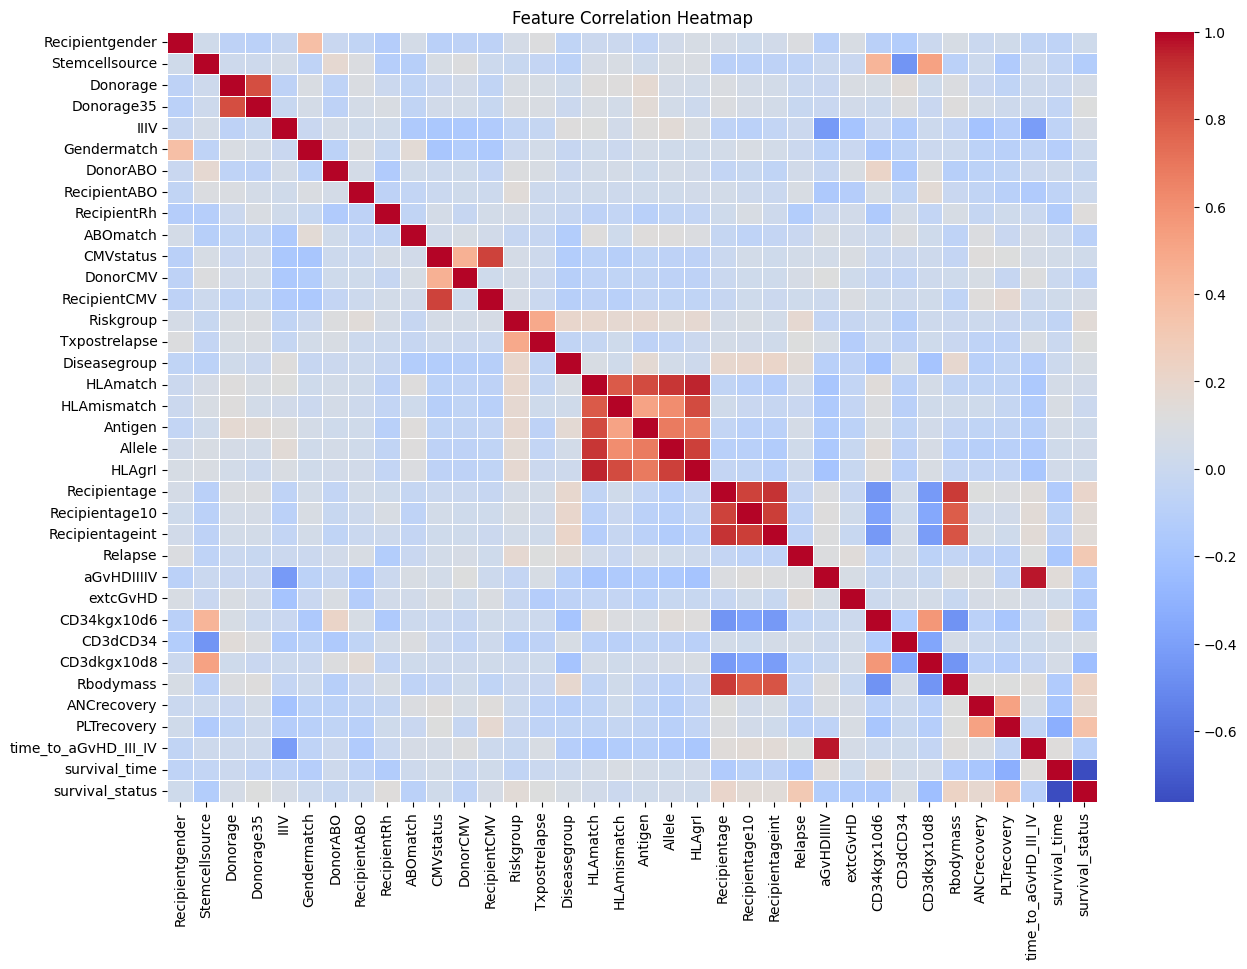

Highly Correlated Pairs:
 aGvHDIIIIV            time_to_aGvHD_III_IV    0.969243
time_to_aGvHD_III_IV  aGvHDIIIIV              0.969243
HLAmatch              HLAgrI                  0.947155
HLAgrI                HLAmatch                0.947155
Recipientageint       Recipientage            0.917351
Recipientage          Recipientageint         0.917351
Allele                HLAmatch                0.903897
HLAmatch              Allele                  0.903897
dtype: float64


In [71]:
# Calculate the correlation matrix
# We only look at numeric columns because correlation needs numbers
corr_matrix = df_cleaned.select_dtypes(include=['number']).corr()

# Create a Heatmap to visualize the relationships
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Find features that are highly correlated (greater than 0.9 or less than -0.9)
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr > 0.9) & (high_corr < 1.0)]
print("Highly Correlated Pairs:\n", high_corr)

The dataset shows a moderate imbalance (~60/40). To address this without losing data (Undersampling) or introducing synthetic bias (SMOTE), I will use Class-weight adjustment during model training. This ensures the model treats both outcomes with equal importance by penalizing minority class errors more heavily.

In [72]:
import sys
import importlib

# Ensure the src folder is in the path
if '../' not in sys.path:
    sys.path.append('../')

# Import the module
import src.data_processing

# Force Python to reload the file so it sees your saved changes
importlib.reload(src.data_processing)

# Now grab the function
from src.data_processing import optimize_memory

# Run the optimization on your cleaned data
df_optimized = optimize_memory(df_cleaned)

Memory usage before optimization: 0.0529 MB
Memory usage after optimization: 0.0178 MB
Decreased by 66.4%


In [73]:
import sys
import importlib

# Ensure the notebook can see the 'src' folder
if '../' not in sys.path:
    sys.path.append('../')

# 1. First, import the module so Python knows it exists
import src.train_model

# 2. Force the reload
importlib.reload(src.train_model)

# 3. Grab the specific function
from src.train_model import train_and_evaluate

# Train the models using your memory-optimized dataframe
trained_models, evaluation_results = train_and_evaluate(df_optimized)

Preparing data for training...

--- Model Evaluation Results ---
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest     0.947      1.000   0.882     0.938    0.968
SVM               0.526      0.455   0.294     0.357    0.759
XGBoost           0.895      0.882   0.882     0.882    0.964


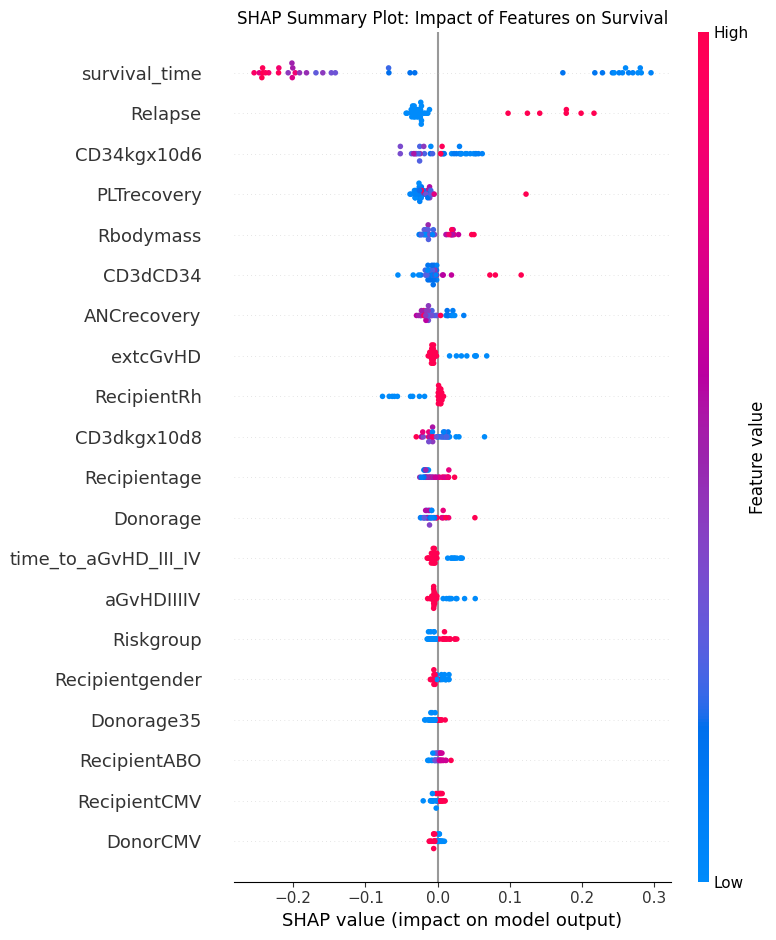

In [77]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Guarantee the numeric dataframe
df_fully_numeric = pd.get_dummies(df_optimized, drop_first=True, dtype=int)

# 2. Recreate the split
X = df_fully_numeric.drop('survival_status', axis=1)
y = df_fully_numeric['survival_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Grab the winning model
rf_model = trained_models['Random Forest']

# 4. Create the Explainer
explainer = shap.TreeExplainer(rf_model)
shap_vals = explainer.shap_values(X_test)

# 5. Safely extract the data for the "Survived" class regardless of SHAP version
if isinstance(shap_vals, list):
    vals_to_plot = shap_vals[1]  # Older SHAP behavior
elif isinstance(shap_vals, np.ndarray) and len(shap_vals.shape) == 3:
    vals_to_plot = shap_vals[:, :, 1]  # Newer SHAP behavior
else:
    vals_to_plot = shap_vals

# 6. Draw the plot
plt.figure(figsize=(10, 6))
shap.summary_plot(vals_to_plot, X_test, show=False)
plt.title("SHAP Summary Plot: Impact of Features on Survival")
plt.tight_layout()
plt.show()

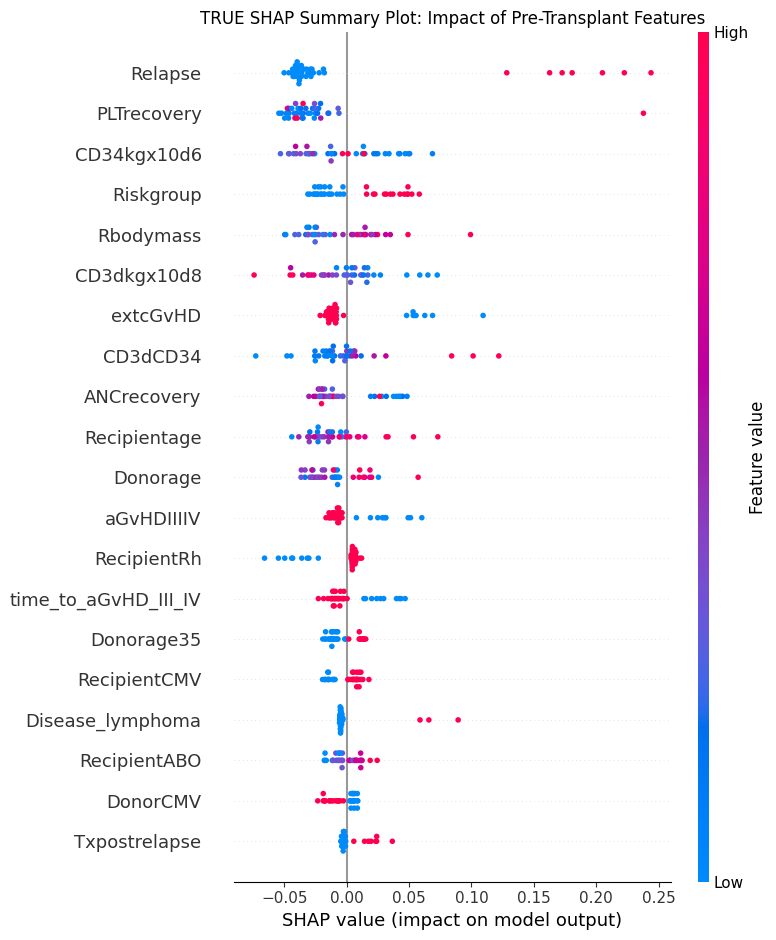

In [78]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Drop BOTH the answer (survival_status) AND the cheating column (survival_time)
X_honest = df_fully_numeric.drop(['survival_status', 'survival_time'], axis=1)
y_honest = df_fully_numeric['survival_status']

# 2. Split the data
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_honest, y_honest, test_size=0.2, random_state=42, stratify=y_honest)

# 3. Retrain the Random Forest honestly
rf_honest = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_honest.fit(X_train_h, y_train_h)

# 4. Generate the TRUE SHAP plot
explainer = shap.TreeExplainer(rf_honest)
shap_vals = explainer.shap_values(X_test_h)

if isinstance(shap_vals, list):
    vals_to_plot = shap_vals[1]
elif isinstance(shap_vals, np.ndarray) and len(shap_vals.shape) == 3:
    vals_to_plot = shap_vals[:, :, 1]
else:
    vals_to_plot = shap_vals

plt.figure(figsize=(10, 6))
shap.summary_plot(vals_to_plot, X_test_h, show=False)
plt.title("TRUE SHAP Summary Plot: Impact of Pre-Transplant Features")
plt.tight_layout()
plt.show()

After removing target leakage (survival_time), the SHAP summary plot revealed the top pre-transplant features that most heavily influenced the model's predictions. The top three driving factors are:

Relapse: The patient's relapse history is the most dominant predictor.

PLTrecovery: Platelet recovery time strongly impacts the model's output.

CD34kgx10d6: The CD34+ cell dose (a measure of stem cell count) is the third most critical feature.
These insights ensure the model is transparent and aligns with clinical expectations.

In [80]:
import joblib
import os

# 1. Ensure the 'app' folder exists right here
os.makedirs('app', exist_ok=True)

# 2. Save the honest Random Forest model
joblib.dump(rf_honest, 'app/rf_model.pkl')

# 3. Save the exact column names
joblib.dump(X_honest.columns.tolist(), 'app/model_columns.pkl')

print("Model successfully saved to the app folder!")

Model successfully saved to the app folder!
